In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
print(tf.__version__)


2.15.0


In [3]:
IMAGE_SIZE = 128
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 20

In [4]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(r"C:\Users\hunny\OneDrive\Desktop\Major_Project_2\Dataset",shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE

)

Found 18160 files belonging to 10 classes.


In [5]:
class_names = dataset.class_names
class_names

['Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [6]:
len(dataset)

568

In [7]:
for image_batch,label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())

(32, 128, 128, 3)
[5 1 6 9 7 3 7 7 7 0 5 7 4 7 0 1 5 6 7 2 4 7 3 5 4 9 1 5 4 5 0 1]


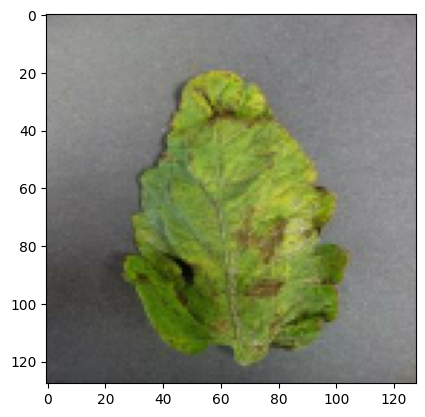

In [8]:
for image_batch,label_batch in dataset.take(1):
    plt.imshow(image_batch[0].numpy().astype("uint8"))

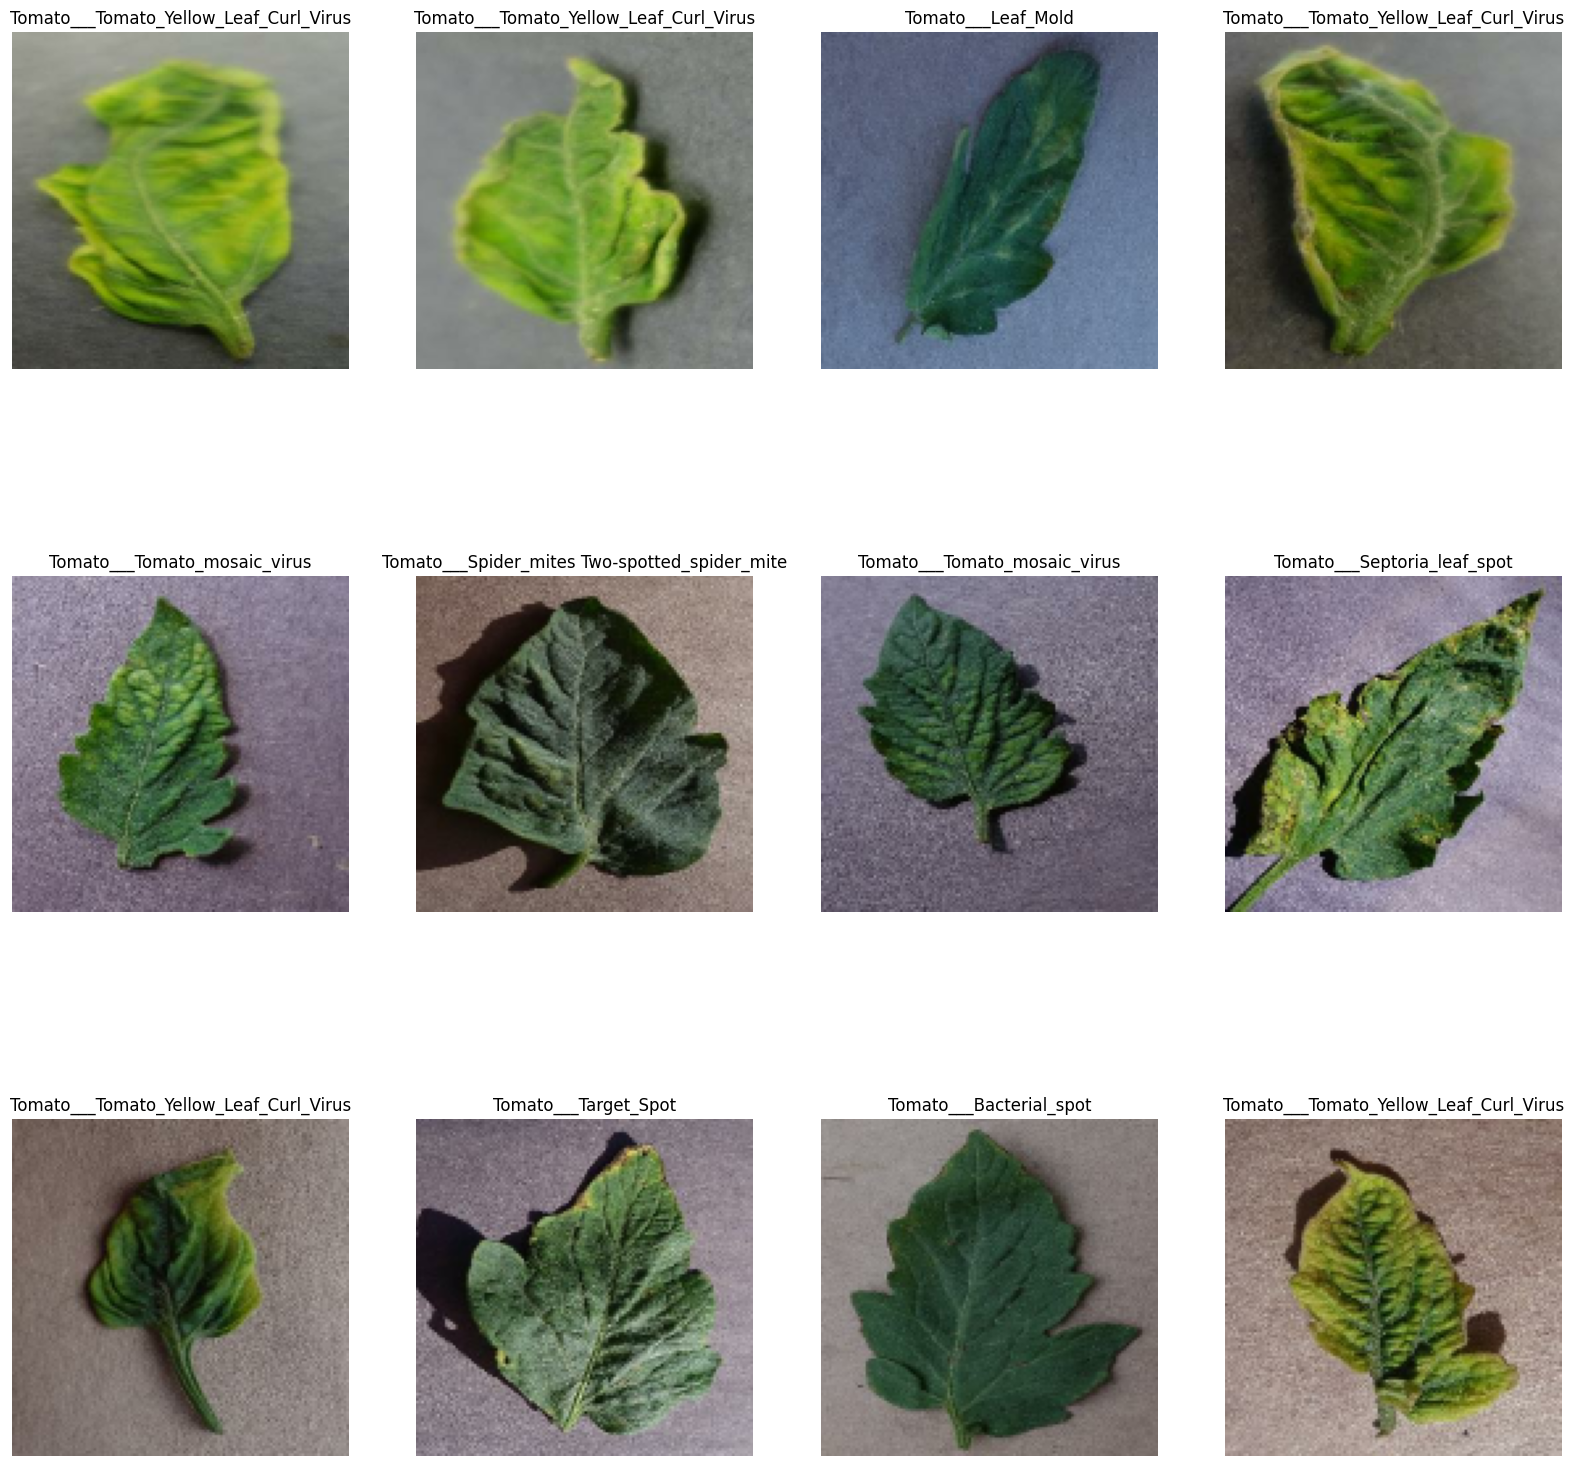

In [9]:
plt.figure(figsize=(20,20))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")


In [10]:
len(dataset)

568

In [11]:
80% ==> training 
20% ==> 10% validation, 10% test

SyntaxError: invalid syntax (937673030.py, line 1)

In [12]:
train_size = 0.8
len(dataset)*train_size


454.40000000000003

In [13]:
train_ds = dataset.take(454)
len(train_ds)

454

In [14]:
test_ds = dataset.skip(454)
len(test_ds)

114

In [15]:
val_size = 0.1
len(dataset)*val_size

56.800000000000004

In [16]:
val_ds = test_ds.take(56)
len(val_ds)

56

In [17]:
test_ds = test_ds.skip(56)
len(test_ds)

58

In [18]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size + val_size)

    return train_ds, val_ds, test_ds



In [19]:
train_ds,val_ds,test_ds = get_dataset_partitions_tf(dataset)

In [20]:
len(train_ds)

454

In [21]:
len(val_ds)

56

In [22]:
len(test_ds)

58

In [23]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [24]:
from tensorflow.keras import layers

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])


In [25]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [26]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))


GPU Available: []


In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

n_classes = len(dataset.class_names)

model = models.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(n_classes, activation='softmax')
])


In [28]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 128, 128, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 128, 128, 32)      128       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 128, 128, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)       

In [29]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [30]:
checkpoint = ModelCheckpoint(
    "best_custom_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


In [32]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    verbose=2,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/20



Epoch 1: val_accuracy improved from -inf to 0.52344, saving model to best_custom_model.keras
454/454 - 110s - loss: 0.4567 - accuracy: 0.8465 - val_loss: 1.8815 - val_accuracy: 0.5234 - 110s/epoch - 242ms/step
Epoch 2/20

Epoch 2: val_accuracy improved from 0.52344 to 0.80804, saving model to best_custom_model.keras
454/454 - 104s - loss: 0.3276 - accuracy: 0.8908 - val_loss: 0.5512 - val_accuracy: 0.8080 - 104s/epoch - 229ms/step
Epoch 3/20

Epoch 3: val_accuracy did not improve from 0.80804
454/454 - 136s - loss: 0.2809 - accuracy: 0.9061 - val_loss: 0.8664 - val_accuracy: 0.7606 - 136s/epoch - 299ms/step
Epoch 4/20

Epoch 4: val_accuracy did not improve from 0.80804
454/454 - 138s - loss: 0.2259 - accuracy: 0.9256 - val_loss: 0.8356 - val_accuracy: 0.7595 - 138s/epoch - 304ms/step
Epoch 5/20

Epoch 5: val_accuracy did not improve from 0.80804
454/454 - 118s - loss: 0.1971 - accuracy: 0.9357 - val_loss: 0.6013 - val_accuracy: 0.7874 - 118s/epoch - 261ms/step


In [33]:
scores = model.evaluate(test_ds)

58/58 [==============================] - 11s 85ms/step - loss: 0.5938 - accuracy: 0.8006


In [34]:
history

In [35]:
scores

[0.5937622785568237, 0.8006465435028076]

In [36]:
import tensorflow as tf

model = tf.keras.models.load_model("best_custom_model.keras")



In [37]:
print("Final Train Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])


Final Train Accuracy: 0.9357084035873413
Final Validation Accuracy: 0.7873883843421936


In [38]:
loss, accuracy = model.evaluate(val_ds)
print("Validation Accuracy:", accuracy)


56/56 [==============================] - 6s 84ms/step - loss: 0.5512 - accuracy: 0.8080
Validation Accuracy: 0.8080357313156128


In [39]:
loss, accuracy = model.evaluate(test_ds)
print("Test Accuracy:", accuracy)


58/58 [==============================] - 5s 86ms/step - loss: 0.5938 - accuracy: 0.8006
Test Accuracy: 0.8006465435028076


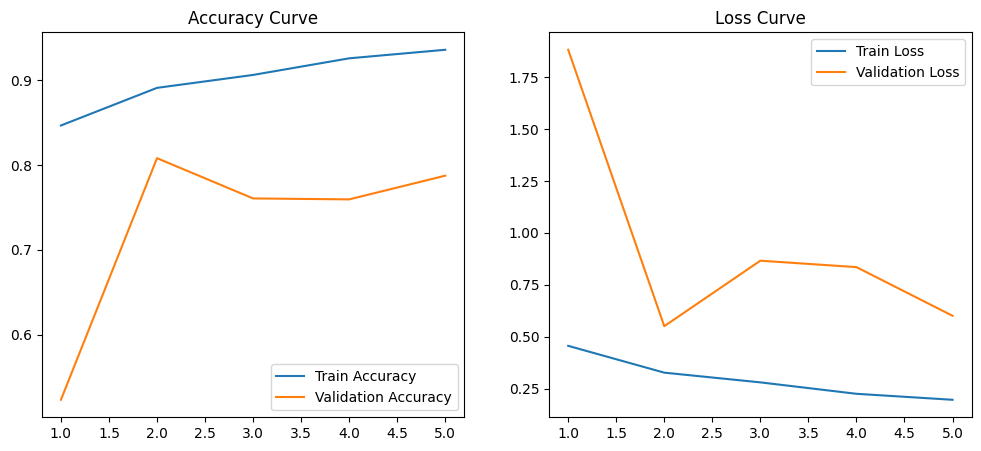

In [40]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Curve')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss Curve')

plt.show()


1/1 [==============================] - 0s 130ms/step


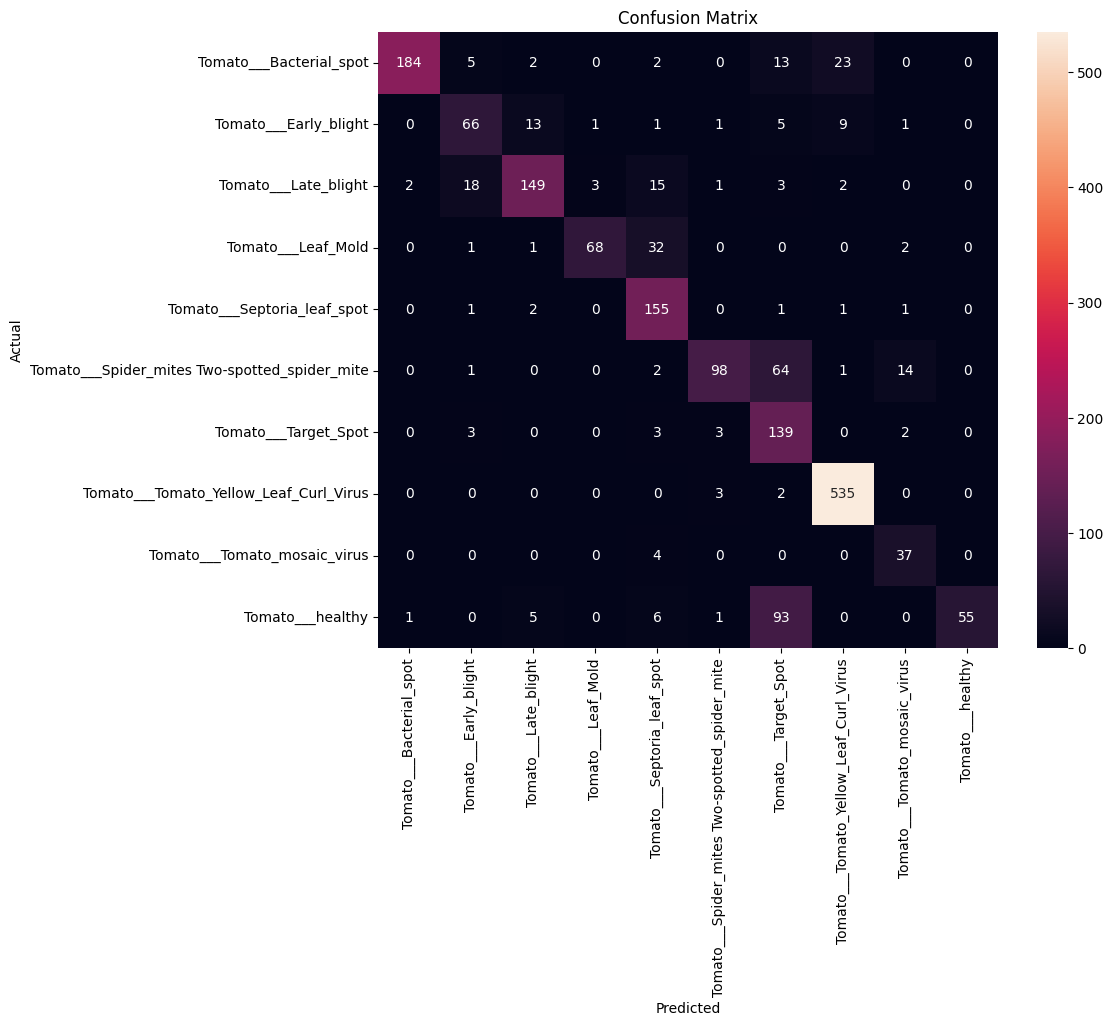

In [42]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=dataset.class_names,
            yticklabels=dataset.class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [43]:
print(classification_report(y_true, y_pred, target_names=dataset.class_names))


                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.98      0.80      0.88       229
                        Tomato___Early_blight       0.69      0.68      0.69        97
                         Tomato___Late_blight       0.87      0.77      0.82       193
                           Tomato___Leaf_Mold       0.94      0.65      0.77       104
                  Tomato___Septoria_leaf_spot       0.70      0.96      0.81       161
Tomato___Spider_mites Two-spotted_spider_mite       0.92      0.54      0.68       180
                         Tomato___Target_Spot       0.43      0.93      0.59       150
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.94      0.99      0.96       540
                 Tomato___Tomato_mosaic_virus       0.65      0.90      0.76        41
                             Tomato___healthy       1.00      0.34      0.51       161

                                     accu

In [59]:
def predict_image(img_path):
    from tensorflow.keras.preprocessing import image
    import numpy as np
    import matplotlib.pyplot as plt

    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0]

    top_2 = np.argsort(prediction)[-2:][::-1]

    print("Top Predictions:")
    for i in top_2:
        print(f"{class_names[i]} : {prediction[i]*100:.2f}%")

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{class_names[top_2[0]]} ({prediction[top_2[0]]*100:.2f}%)")
    plt.show()


In [1]:
predict_image(r"C:\Users\hunny\OneDrive\Desktop\Major_Project_2\Dataset\Tomato___Tomato_mosaic_virus\0a91f50b-1263-4b2c-a8c1-f2a6025b82f3___PSU_CG 2136.JPG")


NameError: name 'predict_image' is not defined

1/1 [==============================] - 0s 58ms/step
Top Predictions:
Tomato___Early_blight : 37.23%
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 30.34%


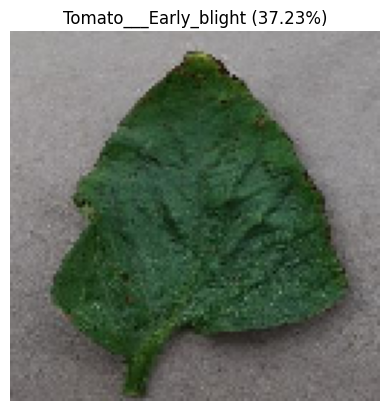

In [62]:
predict_image(r"C:\Users\hunny\OneDrive\Desktop\Major_Project_2\Dataset\Tomato___Bacterial_spot\0a22f50a-5f25-4cf6-816b-76cae94b7f30___GCREC_Bact.Sp 6103.JPG")

In [53]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print("Unique predictions:", np.unique(y_pred))
print("Unique actual labels:", np.unique(y_true))


1/1 [==============================] - 0s 155ms/step
Unique predictions: [0 1 2 3 4 5 6 7 8 9]
Unique actual labels: [0 1 2 3 4 5 6 7 8 9]


In [54]:
class_names = dataset.class_names
print(class_names)


['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [55]:
def predict_image(img_path):
    from tensorflow.keras.preprocessing import image
    import numpy as np
    import matplotlib.pyplot as plt

    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array)

    predicted_index = np.argmax(prediction[0])
    predicted_class = class_names[predicted_index]
    confidence = np.max(prediction[0]) * 100

    print("Predicted Index:", predicted_index)
    print("Prediction Vector:", prediction[0])
    print(f"Prediction: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{predicted_class} ({confidence:.2f}%)")
    plt.show()
